# OPTED Reverse Dictionary — Exploratory Data Analysis

This notebook performs the initial exploratory data analysis for the OPTED reverse-dictionary dataset.

Expected columns:

- `Word`
- `Count`
- `POS`
- `Definition`

The notebook covers:

1. Dataset overview
2. Missing-value analysis
3. Duplicate and multiple-definition analysis
4. Definition-length analysis
5. Vocabulary and POS analysis


## 1. Imports and configuration

In [1]:
from pathlib import Path
from collections import Counter
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)

WORD_COL = "Word"
COUNT_COL = "Count"
POS_COL = "POS"
DEF_COL = "Definition"

FILE_PATH = Path("../data/OPTED-Dictionary.csv")

print(f"Configured dataset path: {FILE_PATH.resolve()}")

Configured dataset path: D:\Git\MLCapstone_ReverseDict\data\OPTED-Dictionary.csv


## 2. Load and validate the dataset

In [2]:
if not FILE_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {FILE_PATH.resolve()}\n"
        "Place OPTED-Dictionary.csv inside the project's data folder or update FILE_PATH."
    )

df = pd.read_csv(FILE_PATH, keep_default_na=False)

required_columns = {WORD_COL, COUNT_COL, POS_COL, DEF_COL}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing expected columns: {sorted(missing_columns)}\n"
        f"Available columns: {df.columns.tolist()}"
    )

print("Dataset loaded successfully.")
display(df.head(10))

Dataset loaded successfully.


,Word,Count,POS,Definition
0,A,1,"""""","""The first letter of the English and of many other alphabets. The capital A of the alphabets of Middle and Western Europe as also the small letter (a) besides the forms in Ita..."
1,A,1,"""""","""The name of the sixth tone in the model major scale (that in C) or the first tone of the minor scale which is named after it the scale in A minor. The second string of the vi..."
2,A,1,"""""","""An adjective commonly called the indefinite article and signifying one or any but less emphatically."""
3,A,1,"""""","""In each; to or for each; as """"""""twenty leagues a day"""""""" """"""""a hundred pounds a year"""""""" """"""""a dollar a yard"""""""" etc."""
4,A,1,"""prep.""","""In; on; at; by."""
5,A,1,"""prep.""","""In process of; in the act of; into; to; -- used with verbal substantives in -ing which begin with a consonant. This is a shortened form of the preposition an (which was used b..."
6,A,1,"""""","""Of."""
7,A,1,"""""","""A barbarous corruption of have of he and sometimes of it and of they."""
8,A,1,"""""","""An expletive void of sense to fill up the meter"""
9,A-,2,"""""","""A as a prefix to English words is derived from various sources. (1) It frequently signifies on or in (from an a forms of AS. on) denoting a state as in afoot on foot abed ami..."


# Task 1 — Dataset overview

In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

overview_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notna().sum().values,
    "Unique Values": df.nunique(dropna=True).values,
})

display(overview_df)
display(df.sample(min(10, len(df)), random_state=42))

DATASET OVERVIEW
Total rows    : 176,009
Total columns : 4
Memory usage  : 46.57 MB


,Column,Data Type,Non-Null Count,Unique Values
0,Word,str,176009,111598
1,Count,str,176009,28
2,POS,str,176009,295
3,Definition,str,176009,166067


,Word,Count,POS,Definition
33497,Convertible,11,"""a.""","""Capable of being converted; susceptible of change; transmutable; transformable."""
128986,Report,6,"""v. t.""","""To bring back as an answer; to announce in return; to relate as what has been discovered by a person sent to examine explore or investigate; as a messenger reports to his emp..."
14701,Bene,4,"""n.""","""See Benne."""
89885,Literal,7,"""n.""","""Literal meaning."""
48677,Dunned,6,"""imp. & p. p.""","""of Dun"""
101114,Naturalization,14,"""n.""","""The act or process of naturalizing esp. of investing an alien with the rights and privileges of a native or citizen; also the state of being naturalized."""
151585,Subjected,9,"""a.""","""Exposed; liable; subject; obnoxious."""
43970,Disarraying,11,"""p. pr. & vb. n.""","""of Disarray"""
117767,Portative,9,"""a.""","""Portable."""
124839,Raddle,6,"""n.""","""A red pigment used in marking sheep and in some mechanical processes; ruddle."""


In [4]:
print("Count column summary:")
display(df[COUNT_COL].describe(include="all"))

print("Sample Count/POS records:")
display(df[[WORD_COL, COUNT_COL, POS_COL, DEF_COL]].head(20))

Count column summary:


count     176009
unique        28
top            8
freq       23821
Name: Count, dtype: object

Sample Count/POS records:


,Word,Count,POS,Definition
0,A,1,"""""","""The first letter of the English and of many other alphabets. The capital A of the alphabets of Middle and Western Europe as also the small letter (a) besides the forms in Ita..."
1,A,1,"""""","""The name of the sixth tone in the model major scale (that in C) or the first tone of the minor scale which is named after it the scale in A minor. The second string of the vi..."
2,A,1,"""""","""An adjective commonly called the indefinite article and signifying one or any but less emphatically."""
3,A,1,"""""","""In each; to or for each; as """"""""twenty leagues a day"""""""" """"""""a hundred pounds a year"""""""" """"""""a dollar a yard"""""""" etc."""
4,A,1,"""prep.""","""In; on; at; by."""
5,A,1,"""prep.""","""In process of; in the act of; into; to; -- used with verbal substantives in -ing which begin with a consonant. This is a shortened form of the preposition an (which was used b..."
6,A,1,"""""","""Of."""
7,A,1,"""""","""A barbarous corruption of have of he and sometimes of it and of they."""
8,A,1,"""""","""An expletive void of sense to fill up the meter"""
9,A-,2,"""""","""A as a prefix to English words is derived from various sources. (1) It frequently signifies on or in (from an a forms of AS. on) denoting a state as in afoot on foot abed ami..."


# Task 2 — Missing-value and blank-value analysis

In [5]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2),
})

display(missing_summary)

,Missing Count,Missing Percentage
Word,0,0.0
Count,0,0.0
POS,0,0.0
Definition,0,0.0


In [6]:
blank_summary = []

for column in [WORD_COL, POS_COL, DEF_COL]:
    blank_count = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    blank_summary.append({
        "Column": column,
        "Blank String Count": int(blank_count),
    })

blank_summary_df = pd.DataFrame(blank_summary)
display(blank_summary_df)

,Column,Blank String Count
0,Word,1
1,POS,0
2,Definition,0


In [7]:
problem_rows = df[
    df[WORD_COL].isna()
    | df[DEF_COL].isna()
    | df[POS_COL].isna()
    | df[WORD_COL].fillna("").astype(str).str.strip().eq("")
    | df[DEF_COL].fillna("").astype(str).str.strip().eq("")
]

print(f"Rows with at least one important missing/blank value: {len(problem_rows):,}")
display(problem_rows.head(30))

Rows with at least one important missing/blank value: 1


,Word,Count,POS,Definition
146499,,0,"""","a game played with such pieces; pushpin."""


# Task 3 — Duplicate and multiple-definition analysis

Repeated words are not automatically errors. A word can legitimately have multiple definitions or parts of speech.

In [8]:
exact_duplicate_count = int(df.duplicated().sum())
duplicate_word_definition_count = int(
    df.duplicated(subset=[WORD_COL, DEF_COL]).sum()
)

duplicate_summary = pd.DataFrame({
    "Metric": [
        "Exact duplicate rows",
        "Repeated Word + Definition pairs",
    ],
    "Count": [
        exact_duplicate_count,
        duplicate_word_definition_count,
    ],
})

display(duplicate_summary)

,Metric,Count
0,Exact duplicate rows,101
1,Repeated Word + Definition pairs,247


In [9]:
exact_duplicates = (
    df[df.duplicated(keep=False)]
    .sort_values([WORD_COL, COUNT_COL, POS_COL], na_position="last")
)

print(f"Rows participating in exact duplicates: {len(exact_duplicates):,}")
display(exact_duplicates.head(30))

Rows participating in exact duplicates: 200


,Word,Count,POS,Definition
37767,#NAME?,#NAME?,"""""","""of Curvet"""
37769,#NAME?,#NAME?,"""""","""of Curvet"""
21860,#NAME?,#NAME?,"""pl. ""","""of Calcaneum"""
21861,#NAME?,#NAME?,"""pl. ""","""of Calcaneum"""
35802,#NAME?,#NAME?,"""pl. ""","""of Crayfish"""
35803,#NAME?,#NAME?,"""pl. ""","""of Crayfish"""
44421,#NAME?,#NAME?,"""pl. ""","""of Discrepancy"""
44422,#NAME?,#NAME?,"""pl. ""","""of Discrepancy"""
59642,#NAME?,#NAME?,"""pl. ""","""of Flagstaff"""
59643,#NAME?,#NAME?,"""pl. ""","""of Flagstaff"""


In [10]:
definitions_per_word = (
    df.groupby(WORD_COL, dropna=False)[DEF_COL]
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

words_with_multiple_definitions = definitions_per_word[
    definitions_per_word > 1
]

print(f"Unique words: {df[WORD_COL].nunique(dropna=True):,}")
print(
    "Words with multiple definitions: "
    f"{len(words_with_multiple_definitions):,}"
)

display(
    words_with_multiple_definitions
    .head(25)
    .rename("Number of Definitions")
    .reset_index()
)

Unique words: 111,598
Words with multiple definitions: 25,196


,Word,Number of Definitions
0,#NAME?,197
1,Run,71
2,Set,59
3,Light,47
4,Round,46
5,Cast,45
6,Strike,44
7,Line,44
8,Rise,42
9,Fall,41


In [11]:
top_multi_definition_words = words_with_multiple_definitions.head(10).index

multi_definition_examples = (
    df[df[WORD_COL].isin(top_multi_definition_words)]
    [[WORD_COL, COUNT_COL, POS_COL, DEF_COL]]
    .sort_values([WORD_COL, COUNT_COL, POS_COL], na_position="last")
)

display(multi_definition_examples)

,Word,Count,POS,Definition
16674,#NAME?,#NAME?,"""""","""A suffix or terminal formative used principally in biological terms and signifying growth formation; as bioblast epiblast mesoblast etc."""
37767,#NAME?,#NAME?,"""""","""of Curvet"""
37769,#NAME?,#NAME?,"""""","""of Curvet"""
46741,#NAME?,#NAME?,"""""","""A suffix denoting"""
46742,#NAME?,#NAME?,"""""","""Jurisdiction or property and jurisdiction dominion as in kingdom earldom."""
...,...,...,...,...
150652,Strike,6,"""v. t.""","""To hit upon or light upon suddenly; as my eye struck a strange word; they soon struck the trail."""
150653,Strike,6,"""v. t.""","""To borrow money of; to make a demand upon; as he struck a friend for five dollars."""
150654,Strike,6,"""v. t.""","""To lade into a cooler as a liquor."""
150655,Strike,6,"""v. t.""","""To stroke or pass lightly; to wave."""


In [12]:
words_per_definition = (
    df.groupby(DEF_COL, dropna=False)[WORD_COL]
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

shared_definitions = words_per_definition[words_per_definition > 1]

print(
    "Definitions mapped to multiple words: "
    f"{len(shared_definitions):,}"
)

display(
    shared_definitions
    .head(25)
    .rename("Number of Words")
    .reset_index()
)

Definitions mapped to multiple words: 8,448


,Definition,Number of Words
0,"""The pintail duck.""",9
1,"""A handkerchief.""",8
2,"""A prostitute.""",8
3,"""Dull; stupid.""",8
4,"""The ruddy duck.""",7
5,"""of Mow""",7
6,"""The yaffle.""",6
7,"""The magpie.""",6
8,"""The lapwing.""",6
9,"""A tern.""",6


# Task 4 — Definition-length analysis

In [13]:
df["definition_char_count"] = (
    df[DEF_COL]
    .fillna("")
    .astype(str)
    .str.len()
)

df["definition_word_count"] = (
    df[DEF_COL]
    .fillna("")
    .astype(str)
    .str.findall(r"\b[\w'-]+\b")
    .str.len()
)

length_statistics = (
    df[["definition_char_count", "definition_word_count"]]
    .describe()
    .round(2)
)

display(length_statistics)

,definition_char_count,definition_word_count
count,176009.00,176009.00
mean,66.69,11.10
std,60.77,10.51
min,2.00,0.00
25%,23.00,3.00
50%,48.00,8.00
75%,90.00,15.00
max,807.00,148.00


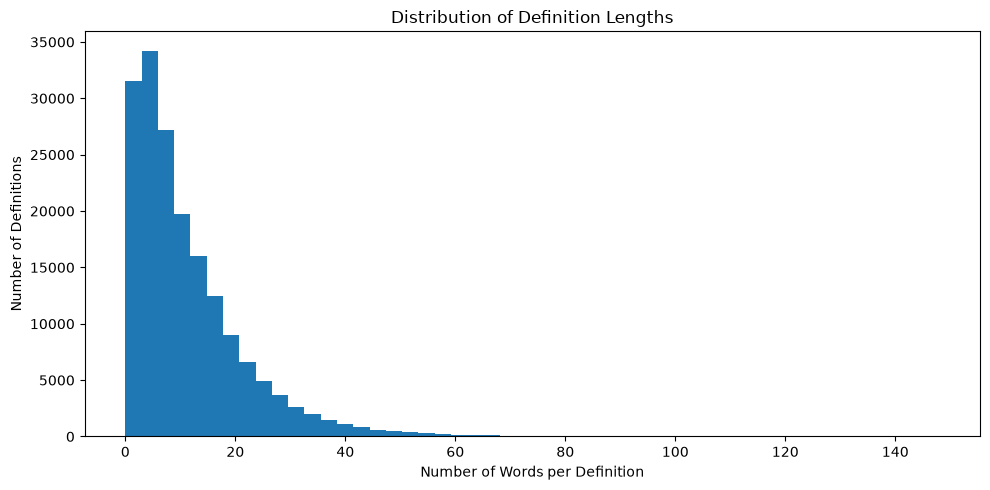

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df["definition_word_count"], bins=50)
plt.title("Distribution of Definition Lengths")
plt.xlabel("Number of Words per Definition")
plt.ylabel("Number of Definitions")
plt.tight_layout()
plt.show()

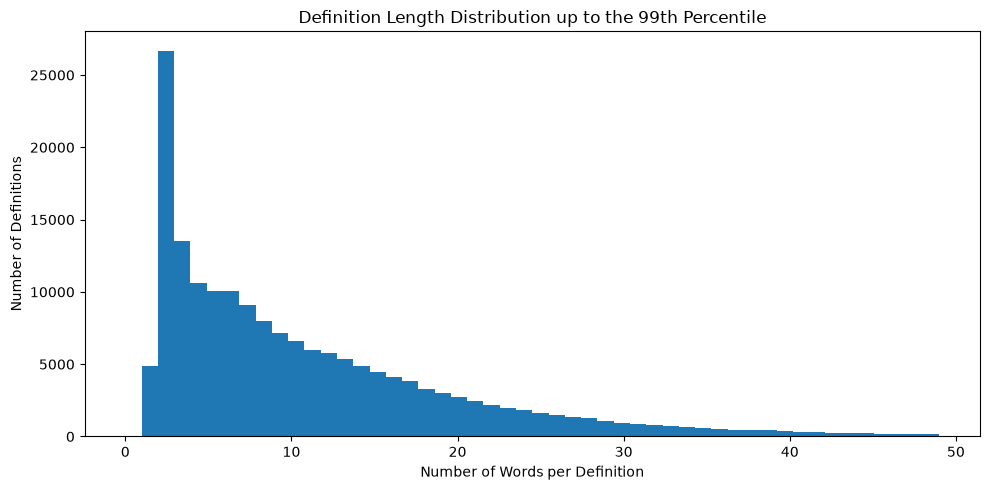

In [15]:
upper_limit = df["definition_word_count"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    df.loc[
        df["definition_word_count"] <= upper_limit,
        "definition_word_count",
    ],
    bins=50,
)
plt.title("Definition Length Distribution up to the 99th Percentile")
plt.xlabel("Number of Words per Definition")
plt.ylabel("Number of Definitions")
plt.tight_layout()
plt.show()

C:\Users\viswa\AppData\Local\Temp\ipykernel_37992\3023514157.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["definition_word_count"].dropna(), vert=False)


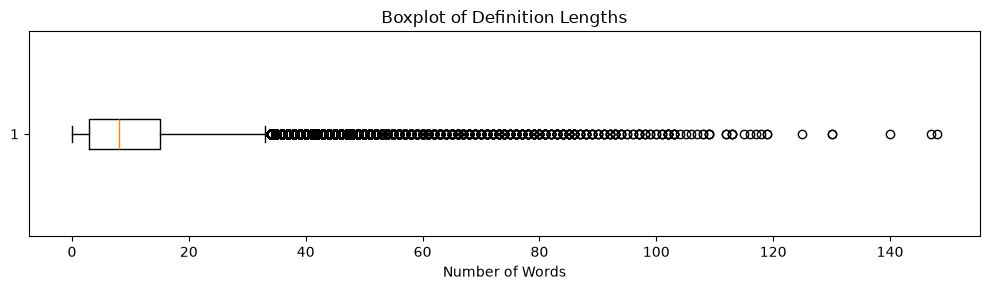

In [16]:
plt.figure(figsize=(10, 3))
plt.boxplot(df["definition_word_count"].dropna(), vert=False)
plt.title("Boxplot of Definition Lengths")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.show()

In [17]:
print("Shortest definitions:")
display(
    df.sort_values("definition_word_count", ascending=True)
    [[WORD_COL, COUNT_COL, POS_COL, DEF_COL, "definition_word_count"]]
    .head(15)
)

print("Longest definitions:")
display(
    df.sort_values("definition_word_count", ascending=False)
    [[WORD_COL, COUNT_COL, POS_COL, DEF_COL, "definition_word_count"]]
    .head(15)
)

Shortest definitions:


,Word,Count,POS,Definition,definition_word_count
6898,Antic,5,"""a.""","""""",0
43831,Dis-,4,"""""",""".""",0
48325,Drum major,10,"""""",""".""",0
53536,#NAME?,#NAME?,"""""",""".""",0
114928,Piracy,6,"""n.""","""""",0
4963,Amatorious,10,"""a.""","""Amatory.""",1
4962,Amatorian,9,"""a.""","""Amatory.""",1
5005,Amber,5,"""n.""","""Ambergris.""",1
4991,Ambagitory,10,"""a.""","""Ambagious.""",1
4989,Ambaginous,10,"""a.""","""Ambagious.""",1


Longest definitions:


,Word,Count,POS,Definition,definition_word_count
17916,Bond,4,"""n.""","""The union or tie of the several stones or bricks forming a wall. The bricks may be arranged for this purpose in several different ways as in English or block bond (Fig. 1) wh...",148
167708,V,1,"""""","""V the twenty-second letter of the English alphabet is a vocal consonant. V and U are only varieties of the same character U being the cursive form while V is better adapted f...",147
141996,Siphon,6,"""n.""","""A device consisting of a pipe or tube bent so as to form two branches or legs of unequal length by which a liquid can be transferred to a lower level as from one vessel to an...",140
158992,Tide,4,"""prep.""","""The alternate rising and falling of the waters of the ocean and of bays rivers etc. connected therewith. The tide ebbs and flows twice in each lunar day or the space of a lit...",130
155837,Tapeworm,8,"""n.""","""Any one of numerous species of cestode worms belonging to Taenia and many allied genera. The body is long flat and composed of numerous segments or proglottids varying in sha...",130
93975,Master,6,"""n.""","""A male person having another living being so far subject to his will that he can in the main control his or its actions; -- formerly used with much more extensive application...",125
49455,Eclipse,7,"""n.""","""An interception or obscuration of the light of the sun moon or other luminous body by the intervention of some other body either between it and the eye or between the luminou...",119
0,A,1,"""""","""The first letter of the English and of many other alphabets. The capital A of the alphabets of Middle and Western Europe as also the small letter (a) besides the forms in Ita...",119
103743,Oak,3,"""n.""","""Any tree or shrub of the genus Quercus. The oaks have alternate leaves often variously lobed and staminate flowers in catkins. The fruit is a smooth nut called an acorn which...",118
164587,Un-,3,"""""","""An inseparable verbal prefix or particle. It is prefixed: (a) To verbs to express the contrary and not the simple negative of the action of the verb to which it is prefixed; ...",117


# Task 5 — Vocabulary and POS analysis

In [18]:
all_definition_text = " ".join(
    df[DEF_COL].dropna().astype(str).tolist()
)

tokens = re.findall(
    r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b",
    all_definition_text.lower(),
)

token_counter = Counter(tokens)

total_tokens = len(tokens)
unique_tokens = len(token_counter)
single_occurrence_tokens = sum(
    frequency == 1 for frequency in token_counter.values()
)

print(f"Total definition tokens    : {total_tokens:,}")
print(f"Unique definition tokens   : {unique_tokens:,}")
print(f"Tokens occurring only once : {single_occurrence_tokens:,}")

Total definition tokens    : 1,956,357
Unique definition tokens   : 73,142
Tokens occurring only once : 30,194


,Token,Frequency
0,of,131548
1,a,114439
2,the,111251
3,to,97431
4,or,88696
5,as,38989
6,in,37961
7,and,26237
8,an,18942
9,by,17799


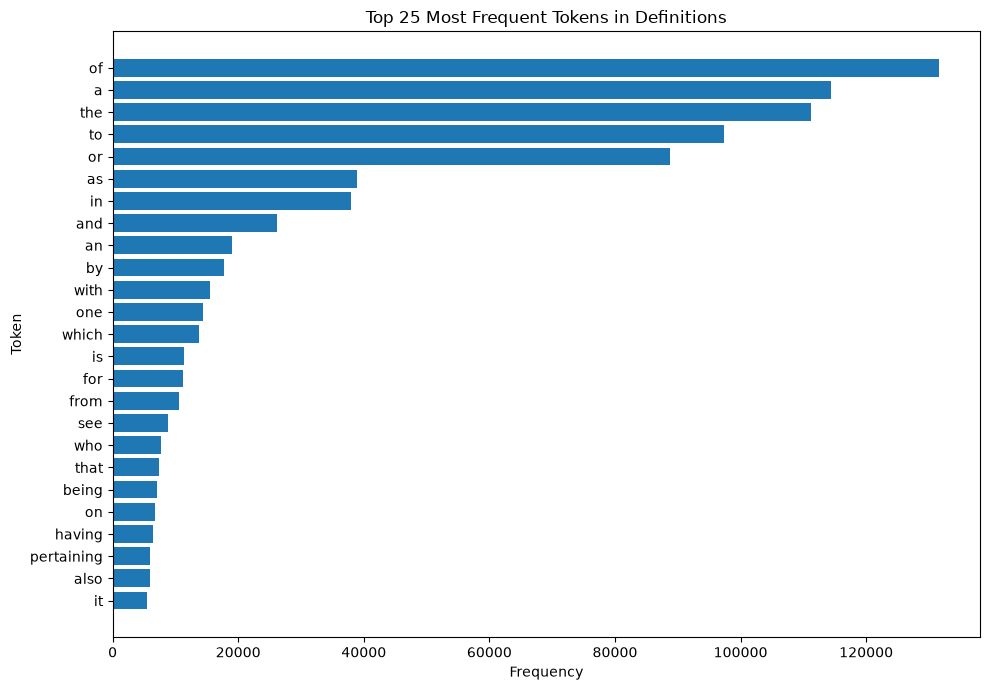

In [19]:
top_tokens_df = pd.DataFrame(
    token_counter.most_common(25),
    columns=["Token", "Frequency"],
)

display(top_tokens_df)

plt.figure(figsize=(10, 7))
plt.barh(
    top_tokens_df["Token"][::-1],
    top_tokens_df["Frequency"][::-1],
)
plt.title("Top 25 Most Frequent Tokens in Definitions")
plt.xlabel("Frequency")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

In [ ]:
df["POS_clean"] = (
    df[POS_COL]
    .fillna("missing")
    .astype(str)
    .str.strip()
    .str.lower()
)

pos_distribution = (
    df["POS_clean"]
    .value_counts(dropna=False)
    .rename_axis("POS")
    .reset_index(name="Count")
)

pos_distribution["Percentage"] = (
    pos_distribution["Count"] / len(df) * 100
).round(2)

display(pos_distribution)

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(pos_distribution["POS"], pos_distribution["Count"])
plt.title("Distribution of Parts of Speech")
plt.xlabel("POS")
plt.ylabel("Number of Entries")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
unique_words_by_pos = (
    df.groupby("POS_clean")[WORD_COL]
    .nunique()
    .sort_values(ascending=False)
    .rename("Unique Words")
    .reset_index()
)

definition_length_by_pos = (
    df.groupby("POS_clean")
    .agg(
        entries=(WORD_COL, "size"),
        unique_words=(WORD_COL, "nunique"),
        average_definition_words=("definition_word_count", "mean"),
        median_definition_words=("definition_word_count", "median"),
    )
    .round(2)
    .sort_values("entries", ascending=False)
    .reset_index()
)

display(unique_words_by_pos)
display(definition_length_by_pos)

In [ ]:
print("Unique POS labels found in the dataset:")
print(sorted(df["POS_clean"].unique()))

# Initial EDA summary

In [ ]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Unique words",
        "Unique definitions",
        "Missing words",
        "Missing definitions",
        "Exact duplicate rows",
        "Words with multiple definitions",
        "Definitions mapped to multiple words",
        "Average definition length (words)",
        "Median definition length (words)",
        "Maximum definition length (words)",
        "Vocabulary size",
        "Unique POS labels",
    ],
    "Value": [
        len(df),
        df[WORD_COL].nunique(dropna=True),
        df[DEF_COL].nunique(dropna=True),
        df[WORD_COL].isna().sum(),
        df[DEF_COL].isna().sum(),
        exact_duplicate_count,
        len(words_with_multiple_definitions),
        len(shared_definitions),
        round(df["definition_word_count"].mean(), 2),
        round(df["definition_word_count"].median(), 2),
        int(df["definition_word_count"].max()),
        unique_tokens,
        df["POS_clean"].nunique(),
    ],
})

display(eda_summary)

## Notes and observations

After running all cells, add your own observations here. For example:

- Whether important columns contain missing values
- Whether duplicate rows appear to be errors or valid repeated dictionary entries
- How many words have multiple definitions
- Which POS categories dominate the dataset
- Whether extremely short or long definitions need later investigation
- Whether POS labels require normalization during preprocessing
